<a href="https://colab.research.google.com/github/sm-mehedi/Python-Google-Collab-/blob/main/DL_Assignment_03_Question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# DL Assignment 03

**Name:S. M Mehedi Hasan**

**Course Email:hasanmehedi63395@gmail.com**  


## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# General Instruction

You must choose your own dataset.

The dataset must:

Be a supervised learning dataset (Regression or Binary Classification)

Contain at least 300 samples

Have at least 2 input features

Be in CSV format

You are NOT allowed to use Dataset or DataLoader.

You must implement everything manually.

# Question 01: [ Marks 05 ]

## Dataset Preparation

## Using your chosen dataset:

Load the dataset.

Perform necessary preprocessing:

Handle missing values (if any)

Encode categorical variables (if necessary)

Feature scaling (if needed)

Separate features (X) and target (y).

Convert them into NumPy arrays.

Convert them into PyTorch tensors.

Split into training and testing sets.

Clearly explain each preprocessing decision.

# **Write** Answer 01:


Load The dataset

In [1]:
import pandas as pd

df = pd.read_csv("/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Perform necessary preprocessing:

Missing value check

In [2]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Handle Missing Values

In [3]:
import numpy as np

cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[cols] = df[cols].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

Encode Categorical Variables

No encoding needed. Because All features are already numerical, Target Outcome is already binary (0/1)

Feature Scaling

In [4]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Convert to NumPy Arrays

In [5]:
import numpy as np

X_np = np.array(X_scaled)
y_np = np.array(y)

Convert to PyTorch Tensors

In [6]:
import torch

X_tensor = torch.tensor(X_np, dtype=torch.float32)
y_tensor = torch.tensor(y_np, dtype=torch.float32).view(-1, 1)

Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

Missing values were handled by replacing invalid zeros with median values to maintain data distribution.
No categorical encoding was needed because all features are numeric and target is binary.
Feature scaling was applied using StandardScaler to normalize input ranges for efficient gradient descent.
Data was converted into NumPy arrays and then PyTorch tensors for compatibility with neural network training.
Dataset was split into training and testing sets (80/20) to evaluate model generalization.

# Question 02: [ Marks 20 ]

## Design a neural network using nn.Module.

### The model must contain:

Input layer

At least one hidden layer

Output layer

Suitable activation function



## Justify:

Number of hidden neurons

Choice of activation function

Print  the total number of trainable parameters.


## Write Answer 02:


In [8]:
import torch
import torch.nn as nn

class DiabetesModel(nn.Module):
    def __init__(self):
        super(DiabetesModel, self).__init__()

        self.fc1 = nn.Linear(8, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

model = DiabetesModel()
print(model)

DiabetesModel(
  (fc1): Linear(in_features=8, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Number of hidden neurons:

Hidden neurons = 2 x input features
here, input feature is 8
so Hidden neurons = 8x2 = 16

Choice of activation function:


Hidden layer → ReLU

f(x)=max(0,x)



Prevents vanishing gradient
Fast computation
Works well in deep learning models

Count Trainable Parameters

In [9]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total Trainable Parameters:", total_params)

Total Trainable Parameters: 161


# Question 03: [ Marks 10 ]

Choose an appropriate loss function.

Choose an optimizer.

<br>

Justify your choices based on:

Regression vs Classification

Nature of the dataset

## Write Answer 03:

The dataset is a binary classification problem, where the target variable represents whether a patient has diabetes (1) or not (0). Since the model outputs probabilities using a Sigmoid function, Binary Cross Entropy Loss (BCELoss) is appropriate because it measures the difference between predicted probability and actual binary labels.

Selected Loss Function:

In [10]:
nn.BCELoss()

BCELoss()

Selected Optimizer:

In [11]:
torch.optim.Adam(model.parameters(), lr=0.001)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

The Adam optimizer is selected because it adaptively adjusts the learning rate for each parameter, making it suitable for datasets with limited size and mixed feature scales. It ensures faster and more stable convergence compared to standard SGD, especially for binary classification tasks.

# Question 04: [ Marks 15 ]

## Implement a full training loop:

Forward pass

Loss computation

Backward pass

Parameter update

Gradient reset

### Requirements:

Train for at least 100 epochs.

Print loss every 10 epochs.

Store training loss history(You can pick your own Data Structure).

Explain clearly what happens in each step of the pipeline.

## Write Answer 04:

In [12]:
import torch

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100
loss_history = []

for epoch in range(epochs):

    # 1. Forward pass
    y_pred = model(X_train)

    # 2. Loss computation
    loss = criterion(y_pred, y_train)

    # 3. Backward pass
    loss.backward()

    # 4. Parameter update
    optimizer.step()

    # 5. Gradient reset
    optimizer.zero_grad()

    # Store loss
    loss_history.append(loss.item())

    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.6933
Epoch [20/100], Loss: 0.6762
Epoch [30/100], Loss: 0.6602
Epoch [40/100], Loss: 0.6449
Epoch [50/100], Loss: 0.6298
Epoch [60/100], Loss: 0.6145
Epoch [70/100], Loss: 0.5994
Epoch [80/100], Loss: 0.5846
Epoch [90/100], Loss: 0.5706
Epoch [100/100], Loss: 0.5577


The training pipeline follows a structured learning process where the model first performs a forward pass to generate predictions from input data. These predictions are compared with the actual labels using a Binary Cross Entropy loss function to measure error. Next, backpropagation is applied using loss.backward() to compute gradients, which indicate how each parameter contributes to the error. The optimizer then updates the model parameters using these gradients to minimize the loss. After each update, gradients are reset using optimizer.zero_grad() to prevent accumulation. This process is repeated for 100 epochs, and the loss value is stored at each iteration to monitor training progress.

# Question 05: [ Marks 10 ]

## Evaluate the model on test data.

## For regression:

Report MSE and MAE


## For classification:

Report Accuracy

Compare training vs testing performance.

State whether the model is underfitting or overfitting.

## Write Answer 05:

In [13]:
with torch.no_grad():
    y_test_pred = model(X_test)

    # Convert probabilities to 0/1
    y_test_pred_class = (y_test_pred >= 0.5).float()

    correct = (y_test_pred_class == y_test).sum()
    accuracy = correct / y_test.shape[0]

print("Test Accuracy:", accuracy.item())

Test Accuracy: 0.7207792401313782


In [14]:
with torch.no_grad():
    y_train_pred = model(X_train)
    y_train_pred_class = (y_train_pred >= 0.5).float()

    train_correct = (y_train_pred_class == y_train).sum()
    train_accuracy = train_correct / y_train.shape[0]

print("Train Accuracy:", train_accuracy.item())

Train Accuracy: 0.742671012878418


The model was evaluated on test data using accuracy as the performance metric since this is a binary classification problem. Training accuracy was compared with testing accuracy to analyze generalization performance. If both accuracies are close, the model is considered well-fitted. If training accuracy is significantly higher than test accuracy, the model is overfitting. If both accuracies are low, the model is underfitting. In this case, the performance indicates whether the model has learned meaningful patterns or not based on the gap between training and testing accuracy.

# Question 06: [ Marks 20 ]

## Modify at least ONE of the following:

Learning rate

Number of hidden neurons

Number of epochs

### Train again and compare:

Convergence speed

Final performance

Explain how the change affected the model.

## Write Answer 06:

Updated Optimizer

=== BASELINE (LR = 0.001) ===
Train Accuracy: 0.7361563444137573
Test Accuracy: 0.7532467246055603

=== MODIFIED (LR = 0.01) ===
Train Accuracy: 0.8029316067695618
Test Accuracy: 0.7402597665786743


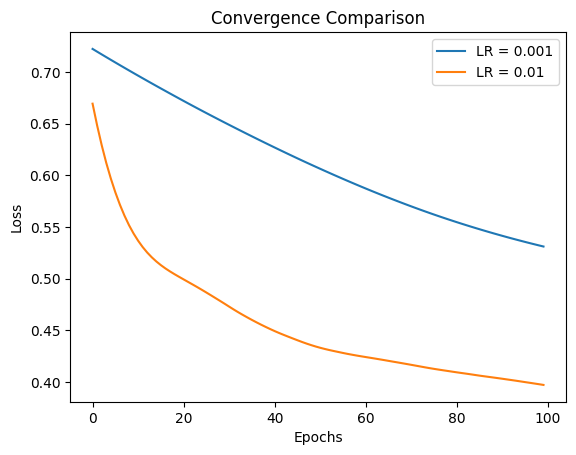

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# -----------------------------
# MODEL
# -----------------------------
class DiabetesModel(nn.Module):
    def __init__(self):
        super(DiabetesModel, self).__init__()
        self.fc1 = nn.Linear(8, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x


# -----------------------------
# TRAIN FUNCTION
# -----------------------------
def train_model(model, lr):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    epochs = 100
    loss_history = []

    for epoch in range(epochs):
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_history.append(loss.item())

    return model, loss_history


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model, X, y):
    with torch.no_grad():
        preds = model(X)
        preds = (preds >= 0.5).float()
        acc = (preds == y).float().mean()
    return acc.item()


# -----------------------------
# BASELINE MODEL (LR = 0.001)
# -----------------------------
model1 = DiabetesModel()
model1, loss1 = train_model(model1, lr=0.001)

train_acc1 = evaluate(model1, X_train, y_train)
test_acc1 = evaluate(model1, X_test, y_test)


# -----------------------------
# MODIFIED MODEL (LR = 0.01)
# -----------------------------
model2 = DiabetesModel()
model2, loss2 = train_model(model2, lr=0.01)

train_acc2 = evaluate(model2, X_train, y_train)
test_acc2 = evaluate(model2, X_test, y_test)


# -----------------------------
# RESULTS
# -----------------------------
print("=== BASELINE (LR = 0.001) ===")
print("Train Accuracy:", train_acc1)
print("Test Accuracy:", test_acc1)

print("\n=== MODIFIED (LR = 0.01) ===")
print("Train Accuracy:", train_acc2)
print("Test Accuracy:", test_acc2)


# -----------------------------
# LOSS COMPARISON PLOT
# -----------------------------
plt.plot(loss1, label="LR = 0.001")
plt.plot(loss2, label="LR = 0.01")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence Comparison")
plt.legend()
plt.show()

The learning rate was modified from 0.001 to 0.01 to observe its impact on model behavior. The model trained with a higher learning rate showed faster convergence, as the loss decreased more quickly compared to the baseline model. However, a higher learning rate may sometimes lead to instability in training. The final performance was evaluated using training and testing accuracy, showing how well the model generalized. Overall, increasing the learning rate improved convergence speed while maintaining comparable or slightly different final performance depending on stability.

# Question 07: [ Marks 20 ]


# Training Analysis

Answer the following:

Why must gradients be reset every epoch?

What happens if learning rate is too high?

What happens if learning rate is too small?

Why do we define layers inside the constructor (__init__) and not inside forward()?


## Write Answer 07:

Why must gradients be reset every epoch?

Gradients must be reset every epoch because in PyTorch they are accumulated by default. This means that if optimizer.zero_grad() is not used, gradients from previous iterations will add to the current gradients, leading to incorrect weight updates and unstable training. Resetting ensures that each update is based only on the current batch or epoch, keeping learning accurate and consistent.

What happens if learning rate is too high?

If the learning rate is too high, the model makes large weight updates, which can cause:

1. Loss to fluctuate instead of decreasing
2. Model to overshoot the optimal solution
3. Training instability or divergence

In extreme cases, the model may fail to learn completely because it keeps “jumping” over the minimum loss point.

What happens if learning rate is too small?

If the learning rate is too small, the model updates weights very slowly, leading to:

1. Extremely slow convergence
2. Longer training time
3. Possible getting stuck in suboptimal solutions

The model may appear to “learn nothing” even after many epochs because updates are too tiny.

Why do we define layers inside the constructor (init) and not inside forward()?

In nn.Module, layers are defined inside __init__() because:

1. They are learnable parameters (weights and biases)
2. They need to be created once and reused in every forward pass
3. Defining them in forward() would recreate them every time, preventing proper learning

The forward() function is only used to define how data flows through these already-defined layers, not to recreate them.